<a href="https://colab.research.google.com/github/Bartimeyss/Ml-contest/blob/main/ml_kontest_yo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"嗨，毫升"

'嗨，毫升'

# Import modules and data

In [ ]:
#%pip install torch
%pip install optuna
%pip install catboost

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import optuna
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler

#import torch as trc

In [ ]:

import os

#download files

os.environ['KAGGLE_USERNAME'] = "nezeritka"
os.environ['KAGGLE_KEY'] = "4da40b42a8f49222ac788d2832884481"
!kaggle competitions download -c scooter-price-prediction-edu-2026
!unzip scooter-price-prediction-edu-2026.zip
!rm scooter-price-prediction-edu-2026.zip



100% 159k/159k [00:00<00:00, 102MB/s]

Archive:  scooter-price-prediction-edu-2026.zip
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
# Проверка загрузки

train_path = f"train.csv"
test_path = f"test.csv"
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)




In [ ]:
#train
print(test.head())
print(train.head())

   id  trip_duration_min  distance_km  battery_level_start  temperature_c  \
0   0          11.328001     2.984336            55.779495       8.091798   
1   1          38.498660    11.646348            82.460577      14.587610   
2   2          12.336503     3.903070            27.184917      26.280163   
3   3          18.232429     5.046844            25.686523            NaN   
4   4          22.992648     8.149461            39.617766       9.642400   

   wind_speed  demand_index  distance_km_noisy city_zone scooter_model  \
0    4.066090      0.663601           1.963757    center             B   
1    0.324484      0.025097          10.144005    suburb             B   
2    0.803103      0.550207           0.263852      park             A   
3    9.745415      0.365754           7.439801    center             B   
4    4.688548      0.991382           6.484963    suburb             B   

   is_weekend  avg_price_last_week  route_complexity  driver_experience  \
0           0    

# Process data



In [ ]:



train = train.drop(columns=['id'], errors='ignore')
test = test.drop(columns=['id'], errors='ignore')
y = train['rental_price']
X = train.drop(columns=['rental_price'])

categorical_columns = ['city_zone', 'scooter_model']
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')
X[numerical_columns] = imputer.fit_transform(X[numerical_columns])
test[numerical_columns] = imputer.transform(test[numerical_columns])

encoder = OneHotEncoder(sparse_output=False)

X_cat = encoder.fit_transform(X[categorical_columns])
test_cat = encoder.transform(test[categorical_columns])

cat_feature_names = encoder.get_feature_names_out(categorical_columns)
X_cat = pd.DataFrame(X_cat, columns=cat_feature_names, index=X.index)
test_cat = pd.DataFrame(test_cat, columns=cat_feature_names, index=test.index)

X = X.drop(columns=categorical_columns)
test = test.drop(columns=categorical_columns)

X = pd.concat([X, X_cat], axis=1)
test = pd.concat([test, test_cat], axis=1)
X = X.drop(columns=['distance_km_noisy']) #у него первый квантиль цена отрицательная
test = test.drop(columns=['distance_km_noisy'])

print(X.head())
print(test.head())

   trip_duration_min  distance_km  battery_level_start  temperature_c  \
0          25.599707     7.441135            78.519717       6.128784   
1          57.289287     8.770495            58.708818      15.947497   
2          45.259667     6.147492            31.714901      26.099837   
3          37.926217     7.740660            86.634377      11.560209   
4          13.581025     3.846835            63.223723      15.542815   

   wind_speed  demand_index  is_weekend  avg_price_last_week  \
0    8.680982      0.861114         0.0             4.985755   
1    8.812507      0.078338         1.0             3.751414   
2    3.501865      0.072575         0.0             2.666093   
3    4.837969      0.850318         1.0             5.835958   
4    7.245579      0.212850         0.0             0.058212   

   route_complexity  driver_experience  weather_rating  city_zone_center  \
0         -0.777649           6.163800             3.0               1.0   
1          1.587773     

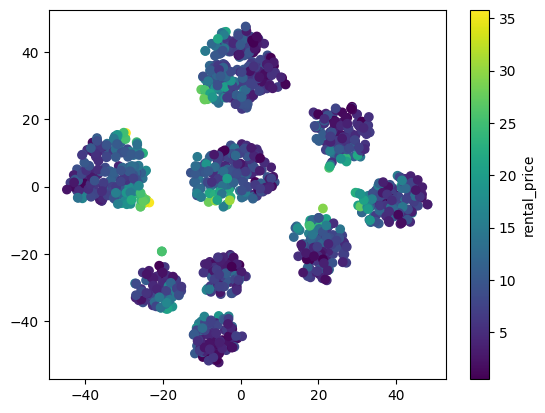

In [ ]:


X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(n_components=2, learning_rate="auto", random_state=69420)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
plt.colorbar(label='rental_price')
plt.show()

In [ ]:
#for col in numerical_columns:
#    print(col, X[col].quantile([0.01, 0.99]))



# Gridsearch or optuna ig

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
study = optuna.create_study(direction="maximize")

def objective(trial):
    param = {
        'verbose': False,
        "n_estimators": trial.suggest_int("n_estimators", 100, 20000),
        "max_depth": trial.suggest_int("max_depth", 2, 16),
        "learning_rate": trial.suggest_float("learning_rate", 5e-4, 0.4),
        "task_type": "GPU"
    }
    model = CatBoostRegressor(**param)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    preds = model.predict(X_test)
    return r2_score(y_test, preds)

study.optimize(objective, n_trials=5)
print(study.best_value)


[I 2026-04-13 13:22:30,849] A new study created in memory with name: no-name-cbf48ec2-0d6f-4e94-8cd5-9553abe9f42c
[I 2026-04-13 13:22:33,365] Trial 0 finished with value: 0.862809575923468 and parameters: {'n_estimators': 6002, 'max_depth': 8, 'learning_rate': 0.27223499704653703}. Best is trial 0 with value: 0.862809575923468.
[I 2026-04-13 13:22:36,347] Trial 1 finished with value: 0.8605460689918388 and parameters: {'n_estimators': 13629, 'max_depth': 9, 'learning_rate': 0.1911361424705828}. Best is trial 0 with value: 0.862809575923468.
[I 2026-04-13 13:22:40,693] Trial 2 finished with value: 0.8610109195368458 and parameters: {'n_estimators': 1924, 'max_depth': 3, 'learning_rate': 0.061017417829837314}. Best is trial 0 with value: 0.862809575923468.
[I 2026-04-13 13:22:41,980] Trial 3 finished with value: 0.8613297163368133 and parameters: {'n_estimators': 6036, 'max_depth': 5, 'learning_rate': 0.16698598470788883}. Best is trial 0 with value: 0.862809575923468.
[I 2026-04-13 13:2

0.862809575923468


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

models = {
    "CatBoost": CatBoostRegressor(verbose=False),
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R2:", r2_score(y_test, preds))